# Football Transfer Fee Prediction Pipeline

This notebook implements a clean, production-oriented version of the transfer fee prediction model. It includes data extraction, sophisticated feature engineering (including FIFA ratings integration), and model evaluation using both Linear Regression and Random Forest Regressor.

## 1. Environment Setup and Data Loading

In [1]:
!pip install fuzzywuzzy


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import os
import zipfile
import unicodedata
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from fuzzywuzzy import process

# Constants
TRANSFERS_PATH = '../data/transfers.zip'
RATINGS_PATH = '../data/ratings.zip'

def normalize_text(s):
    if not isinstance(s, str): return s
    return unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('utf-8')

transfers = pd.read_csv(TRANSFERS_PATH, compression='zip')
transfers.head()

C:\Users\thoma\AppData\Local\Programs\Python\Python313\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season,Market_value,Transfer_fee
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000-2001,NaN,60000000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,2000-2001,NaN,56810000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000-2001,NaN,40000000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000-2001,NaN,36150000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000-2001,NaN,34500000


## 2. Initial Data Cleaning

We clean the seasons, normalize positions, and remove inconsistent rows (e.g., Age 0).

In [3]:
transfers['Season_transferred']=transfers['Season'].str.split('-').str[0]
transfers = transfers.astype({'Season_transferred':'int64'})
transfers = transfers.drop(columns =['Season'])
transfers.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Market_value,Transfer_fee,Season_transferred
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,NaN,60000000,2000
1,Hernán Crespo,Centre-Forward,25,Parma,Serie A,Lazio,Serie A,NaN,56810000,2000
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,NaN,40000000,2000
3,Gabriel Batistuta,Centre-Forward,31,Fiorentina,Serie A,AS Roma,Serie A,NaN,36150000,2000
4,Nicolas Anelka,Centre-Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,NaN,34500000,2000


In [4]:
print(transfers.Position.unique())
transfers.Position = transfers.Position.replace(to_replace=['Second Striker','Centre-Forward','Sweeper'],value = ['Forward','Forward','Defender'])
print(transfers.Position.unique())

['Right Winger' 'Centre-Forward' 'Left Winger' 'Centre-Back'
 'Central Midfield' 'Attacking Midfield' 'Defensive Midfield'
 'Second Striker' 'Goalkeeper' 'Right-Back' 'Left Midfield' 'Left-Back'
 'Right Midfield' 'Forward' 'Sweeper' 'Defender' 'Midfielder']
['Right Winger' 'Forward' 'Left Winger' 'Centre-Back' 'Central Midfield'
 'Attacking Midfield' 'Defensive Midfield' 'Goalkeeper' 'Right-Back'
 'Left Midfield' 'Left-Back' 'Right Midfield' 'Defender' 'Midfielder']


In [5]:
transfers.Age.unique()
transfers_weird = transfers.loc[transfers.Age == 0]
print(transfers_weird)

                  Name Position  Age Team_from    League_from  Team_to  \
236  Marzouq Al-Otaibi  Forward    0    Shabab   Saudi Arabia  Ittihad   

         League_to  Market_value  Transfer_fee  Season_transferred  
236   Saudi Arabia           NaN       2000000                2000  


In [6]:
transfers_midfield = transfers.loc[transfers.Position == 'Midfielder']
print(transfers_midfield.head(20))
transfers_defenders = transfers.loc[transfers.Position =='Defender']
print(transfers_defenders.head(20))

             Name    Position  Age Team_from     League_from Team_to  \
705  Tony Dinning  Midfielder   27    Wolves  First Division   Wigan   

                       League_to  Market_value  Transfer_fee  \
705  Second Division (bis 03/04)           NaN       1130000   

     Season_transferred  
705                2002  
                Name  Position  Age      Team_from     League_from  \
471    Thomas Hengen  Defender   26  VfL Wolfsburg    1.Bundesliga   
652  Sergio Hellings  Defender   17       Ajax U19  U19 Eredivisie   

            Team_to     League_to  Market_value  Transfer_fee  \
471  1.FC K'lautern  1.Bundesliga           NaN       2250000   
652  Anderlecht U19       Belgium           NaN       2000000   

     Season_transferred  
471                2001  
652                2002  


In [7]:
transfers_cleaned= transfers[~((transfers.Position=='Midfielder')|(transfers.Position=='Defender')|(transfers.Age ==0))]
transfers_cleaned['Transfer_fee_in_mln']=transfers_cleaned['Transfer_fee']/1000000
transfers_cleaned['Market_value_in_mln']=transfers_cleaned['Market_value']/1000000
transfers_cleaned = transfers_cleaned.drop(labels = ['Transfer_fee','Market_value'],axis = 1)
pd.to_datetime(transfers_cleaned['Season_transferred'],format ='%Y')
transfers_cleaned.head()

C:\Users\thoma\AppData\Local\Temp\ipykernel_15932\871180933.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transfers_cleaned['Transfer_fee_in_mln']=transfers_cleaned['Transfer_fee']/1000000
C:\Users\thoma\AppData\Local\Temp\ipykernel_15932\871180933.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transfers_cleaned['Market_value_in_mln']=transfers_cleaned['Market_value']/1000000


,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln
0,Luís Figo,Right Winger,27,FC Barcelona,LaLiga,Real Madrid,LaLiga,2000,60.00,NaN
1,Hernán Crespo,Forward,25,Parma,Serie A,Lazio,Serie A,2000,56.81,NaN
2,Marc Overmars,Left Winger,27,Arsenal,Premier League,FC Barcelona,LaLiga,2000,40.00,NaN
3,Gabriel Batistuta,Forward,31,Fiorentina,Serie A,AS Roma,Serie A,2000,36.15,NaN
4,Nicolas Anelka,Forward,21,Real Madrid,LaLiga,Paris SG,Ligue 1,2000,34.50,NaN


In [8]:
season_fee_stats = (
    transfers_cleaned
    .groupby('Season_transferred')['Transfer_fee_in_mln']
    .agg(mean_transfer_fee='mean', median_transfer_fee='median')
    .reset_index()
) #saving aggregate stats if called back later

## 3. Feature Engineering: Basic Features

Extracting Lastnames and normalizing text for reliable merging.

In [9]:
transfers_2015_18 = transfers_cleaned[transfers_cleaned['Season_transferred'] > 2014].copy()
transfers_2015_18['Lastname'] = transfers_2015_18['Name'].apply(lambda x: x.split(' ')[-1])

for col in ['Lastname', 'Team_from', 'Team_to']:
    transfers_2015_18[col] = transfers_2015_18[col].apply(normalize_text)

transfers_2015_18.head()

,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,Lastname
3713,Kevin De Bruyne,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,Bruyne
3714,Raheem Sterling,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,Sterling
3715,Ángel Di María,Right Winger,27,Man Utd,Premier League,Paris SG,Ligue 1,2015,63.0,50.0,Maria
3716,Anthony Martial,Left Winger,19,Monaco,Ligue 1,Man Utd,Premier League,2015,60.0,8.0,Martial
3717,Alex Teixeira,Attacking Midfield,26,Shakhtar D.,Premier Liga,JS Suning,Super League,2015,50.0,30.0,Teixeira


In [10]:
import zipfile

ratings_zip_path = '../data/ratings.zip'
with zipfile.ZipFile(ratings_zip_path) as zf:
    fifa_full_15 = pd.read_csv(zf.open('players_15.csv'))
    fifa_full_16 = pd.read_csv(zf.open('players_16.csv'))
    fifa_full_17 = pd.read_csv(zf.open('players_17.csv'))
    fifa_full_18 = pd.read_csv(zf.open('players_18.csv'))

fifa_full_15['Season'] = 2015
fifa_full_16['Season'] = 2016
fifa_full_17['Season'] = 2017
fifa_full_18['Season'] = 2018

# Quick schema inspection
print("Shapes:")
print("2015:", fifa_full_15.shape, "2016:", fifa_full_16.shape, "2017:", fifa_full_17.shape, "2018:", fifa_full_18.shape)

print("\nColumn count by year:")
print(len(fifa_full_15.columns), len(fifa_full_16.columns), len(fifa_full_17.columns), len(fifa_full_18.columns))

print("\nDo all years have identical columns?",
      set(fifa_full_15.columns) == set(fifa_full_16.columns) == set(fifa_full_17.columns) == set(fifa_full_18.columns))

# Merge full datasets for broader inspection
fifas_full_merged = pd.concat([fifa_full_15, fifa_full_16, fifa_full_17, fifa_full_18], ignore_index=True, sort=False)

print("\nMerged full dataset shape:", fifas_full_merged.shape)
print("\nFirst 50 columns:")
print(fifas_full_merged.columns[:50].tolist())

fifas_full_merged.head()
fifas_full_merged.sample(5, random_state=42)

Shapes:
2015: (15465, 105) 2016: (14881, 105) 2017: (17009, 105) 2018: (17592, 105)

Column count by year:
105 105 105 105

Do all years have identical columns? True

Merged full dataset shape: (64947, 105)

First 50 columns:
['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob', 'height_cm', 'weight_kg', 'nationality', 'club', 'overall', 'potential', 'value_eur', 'wage_eur', 'player_positions', 'preferred_foot', 'international_reputation', 'weak_foot', 'skill_moves', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'team_position', 'team_jersey_number', 'loaned_from', 'joined', 'contract_valid_until', 'nation_position', 'nation_jersey_number', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'gk_speed', 'gk_positioning', 'player_traits', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribb

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,Season
52569,192890,https://sofifa.com/player/192890/erbin-trejo/1...,E. Trejo,Erbín Trejo,27,1990-06-03,171,69,Mexico,Querétaro,...,66+1,66+1,66+1,67+1,66+1,62+1,62+1,62+1,66+1,2018
35671,194730,https://sofifa.com/player/194730/juan-carlos-m...,Juan Carlos,Juan Carlos Martín Corral,28,1988-01-20,187,82,Spain,Elche CF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017
273,152554,https://sofifa.com/player/152554/gael-clichy/1...,G. Clichy,Gaël Clichy,28,1985-07-26,176,65,France,Manchester City,...,75+1,75+1,75+1,80+1,79+1,76+1,76+1,76+1,79+1,2015
16234,188942,https://sofifa.com/player/188942/victor-wanyam...,V. Wanyama,Victor Wanyama,24,1991-06-25,188,76,Kenya,Southampton,...,77+0,77+0,77+0,75+0,75+0,80+0,80+0,80+0,75+0,2016
20660,206018,https://sofifa.com/player/206018/igor-vetokele...,I. Vetokele,Igor Vetokele,23,1992-03-23,173,74,Angola,Charlton Athletic,...,45+0,45+0,45+0,50+0,47+0,42+0,42+0,42+0,47+0,2016


## 4. Advanced Feature Engineering: FIFA Ratings Integration

We load FIFA player ratings (Overall/Potential) and use multiple fallback strategies to recover missing metadata like Nationality.

In [11]:
nat_frames = []
with zipfile.ZipFile(RATINGS_PATH) as zf:
    for yr in [2015, 2016, 2017, 2018]:
        f = pd.read_csv(zf.open(f'players_{yr-2000}.csv'))
        nat_col = 'nationality_name' if 'nationality_name' in f.columns else ('nationality' if 'nationality' in f.columns else None)
        if nat_col is None: continue

        mini = f[['short_name', 'club', nat_col, 'overall', 'potential']].copy()
        mini['Lastname'] = mini['short_name'].str.split(' ').str[-1].apply(normalize_text)
        mini['club'] = mini['club'].apply(normalize_text)
        mini['Season_transferred'] = yr
        mini = mini.rename(columns={nat_col: 'Nationality'})
        nat_frames.append(mini)

fifa_nat = pd.concat(nat_frames, ignore_index=True)
fifa_nat['Nationality'] = fifa_nat['Nationality'].apply(normalize_text)

fifa_nat_best_club = fifa_nat.sort_values('overall', ascending=False).drop_duplicates(subset=['Lastname', 'club', 'Season_transferred'])
fifa_nat_best_name_season = fifa_nat.sort_values('overall', ascending=False).drop_duplicates(subset=['Lastname', 'Season_transferred'])

print(f'FIFA lookup rows (club-level): {len(fifa_nat_best_club)}')
print(f'FIFA lookup rows (lastname-season): {len(fifa_nat_best_name_season)}')

FIFA lookup rows (club-level): 63797
FIFA lookup rows (lastname-season): 46302


## 5. Dataset Merging and Fallback Recovery

We attempt to match transfers to FIFA data using Team_from, then Team_to, and finally a broader Lastname+Season search.

In [12]:
# Merge on Team_from
transfers_fe = transfers_2015_18.merge(
    fifa_nat_best_club.rename(columns={'club': 'Team_from', 'overall': 'overall_from', 'potential': 'potential_from'}),
    on=['Lastname', 'Team_from', 'Season_transferred'], how='left'
)

# Fallback on Team_to for nulls
null_mask = transfers_fe['overall_from'].isna()
to_lookup = fifa_nat_best_club.rename(columns={'club': 'Team_to', 'overall': 'overall_to', 'potential': 'potential_to', 'Nationality': 'Nat_to'})
transfers_fe = transfers_fe.merge(to_lookup, on=['Lastname', 'Team_to', 'Season_transferred'], how='left')

# Final broader fallback
transfers_fe['overall'] = transfers_fe['overall_from'].combine_first(transfers_fe['overall_to'])
transfers_fe['potential'] = transfers_fe['potential_from'].combine_first(transfers_fe['potential_to'])

final_df = transfers_fe.dropna(subset=['overall']).copy()
print(f"Nationality nulls after fallback: {final_df['Nationality'].isna().sum()} / {len(final_df)}")

Nationality nulls after fallback: 40 / 382


## 6. Engineered Indicators for Bias and Performance

Creating buckets for Age and Position, and purchasing power indicators for leagues and clubs.

In [13]:
#Purchasing power proxy
league_median = final_df.groupby('League_to')['Transfer_fee_in_mln'].median()
final_df['league_median_fee_to'] = final_df['League_to'].map(league_median)

# Seasonal market normalization: account for inflation/deflation across years
# Compute mean transfer fee per season to normalize for market changes over time
season_mean_fee = final_df.groupby('Season_transferred')['Transfer_fee_in_mln'].mean()
final_df['season_mean_fee'] = final_df['Season_transferred'].map(season_mean_fee)
# Create season-normalized fee: transfer fee relative to that year's market average
final_df['fee_relative_to_season'] = final_df['Transfer_fee_in_mln'] / final_df['season_mean_fee']
print(f"Season mean transfer fees:\n{season_mean_fee.round(3)}\n")

# Age buckets
final_df['age_bucket'] = pd.cut(final_df['Age'], bins=[14, 20, 24, 27, 30, 50], labels=['<20', '20-23', '24-26', '27-29', '30+'])

# Position buckets
pos_map = {
    'Centre-Back': 'Defender', 'Right-Back': 'Defender', 'Left-Back': 'Defender',
    'Central Midfield': 'Midfielder', 'Attacking Midfield': 'Midfielder', 'Defensive Midfield': 'Midfielder',
    'Right Winger': 'Winger', 'Left Winger': 'Winger', 'Forward': 'Forward', 'Goalkeeper': 'Goalkeeper'
}
final_df['pos_group'] = final_df['Position'].map(pos_map).fillna('Other')

# Region mapping for fairness audits (continental aggregation when single-country n is small).
REGION_MAP = {
    'Brazil': 'South America', 'Argentina': 'South America', 'Colombia': 'South America',
    'Uruguay': 'South America', 'Chile': 'South America', 'Paraguay': 'South America',
    'Ecuador': 'South America', 'Peru': 'South America', 'Venezuela': 'South America',
    'France': 'W. Europe', 'Spain': 'W. Europe', 'Germany': 'W. Europe',
    'Italy': 'W. Europe', 'Portugal': 'W. Europe', 'Netherlands': 'W. Europe',
    'Belgium': 'W. Europe', 'England': 'W. Europe', 'Switzerland': 'W. Europe',
    'Austria': 'W. Europe', 'Scotland': 'W. Europe', 'Wales': 'W. Europe',
    'Republic of Ireland': 'W. Europe', 'Denmark': 'W. Europe', 'Sweden': 'W. Europe',
    'Norway': 'W. Europe', 'Finland': 'W. Europe',
    'Poland': 'E. Europe', 'Czech Republic': 'E. Europe', 'Croatia': 'E. Europe',
    'Serbia': 'E. Europe', 'Bosnia Herzegovina': 'E. Europe', 'Romania': 'E. Europe',
    'Hungary': 'E. Europe', 'Slovakia': 'E. Europe', 'Slovenia': 'E. Europe',
    'Bulgaria': 'E. Europe', 'Ukraine': 'E. Europe', 'Russia': 'E. Europe',
    'Greece': 'E. Europe', 'Turkey': 'E. Europe', 'Albania': 'E. Europe',
    'Montenegro': 'E. Europe', 'Georgia': 'E. Europe',
    'Senegal': 'Africa', 'Ivory Coast': 'Africa', "Côte d'Ivoire": 'Africa',
    'Ghana': 'Africa', 'Nigeria': 'Africa', 'Cameroon': 'Africa',
    'DR Congo': 'Africa', 'Mali': 'Africa', 'Guinea': 'Africa', 'Gabon': 'Africa',
    'Morocco': 'Africa', 'Algeria': 'Africa', 'Tunisia': 'Africa', 'Egypt': 'Africa',
    'Congo': 'Africa',
    'Mexico': 'Americas (other)', 'United States': 'Americas (other)',
    'Canada': 'Americas (other)', 'Jamaica': 'Americas (other)',
    'Costa Rica': 'Americas (other)', 'Honduras': 'Americas (other)',
    'Japan': 'Asia & Oceania', 'South Korea': 'Asia & Oceania',
    'Australia': 'Asia & Oceania', 'Iran': 'Asia & Oceania',
}
_region_check = final_df['Nationality'].map(REGION_MAP).fillna('Other')
print(f"Region coverage: {(_region_check != 'Other').sum()}/{len(final_df)} rows mapped to a known region")
del _region_check

final_df.head()

Season mean transfer fees:
Season_transferred
2015    15.936
2016    17.512
2017    22.664
2018    13.582
Name: Transfer_fee_in_mln, dtype: float64



,Name,Position,Age,Team_from,League_from,Team_to,League_to,Season_transferred,Transfer_fee_in_mln,Market_value_in_mln,...,Nat_to,overall_to,potential_to,overall,potential,league_median_fee_to,season_mean_fee,fee_relative_to_season,age_bucket,pos_group
0,Kevin De Bruyne,Attacking Midfield,24,VfL Wolfsburg,1.Bundesliga,Man City,Premier League,2015,76.0,45.0,...,NaN,NaN,NaN,81.0,86.0,14.55,15.936458,4.768939,20-23,Midfielder
1,Raheem Sterling,Right Winger,20,Liverpool,Premier League,Man City,Premier League,2015,63.7,40.0,...,NaN,NaN,NaN,80.0,86.0,14.55,15.936458,3.997124,<20,Winger
5,Christian Benteke,Forward,24,Aston Villa,Premier League,Liverpool,Premier League,2015,46.5,20.0,...,NaN,NaN,NaN,80.0,85.0,14.55,15.936458,2.917838,20-23,Forward
6,Nicolás Otamendi,Centre-Back,27,Valencia CF,LaLiga,Man City,Premier League,2015,44.6,25.0,...,NaN,NaN,NaN,80.0,84.0,14.55,15.936458,2.798614,24-26,Defender
7,Julian Draxler,Central Midfield,21,FC Schalke 04,1.Bundesliga,VfL Wolfsburg,1.Bundesliga,2015,43.0,22.0,...,NaN,NaN,NaN,80.0,85.0,10.25,15.936458,2.698216,20-23,Midfielder


# Fairness Framework

In [14]:
# Fairness framework for model evaluation
FAIRNESS_FRAMEWORK = {
    'objective': 'Check whether prediction quality and direction of error differ across groups.',
    'target': 'Transfer_fee_in_mln',
    'model_under_evaluation': 'Baseline Random Forest (no engineered FIFA features)',
    'sensitive_or_context_groups': ['League_from', 'Nationality', 'Region'],
    'minimum_group_size': 20,
    'metrics': [
        'Signed residual (mean/median): detect over- vs underprediction by group',
        'MAE and RMSE: compare error magnitude by group',
        'Calibration by predicted-fee quintile x group: check conditional bias at similar predicted values',
    ],
    'interpretation_notes': [
        'Negative residual means underprediction (actual fee > predicted fee).',
        'Positive residual means overprediction (actual fee < predicted fee).',
        'Group-level results should be interpreted with sample-size caution.',
    ],
}

for k, v in FAIRNESS_FRAMEWORK.items():
    print(f"{k}: {v}")

objective: Check whether prediction quality and direction of error differ across groups.
target: Transfer_fee_in_mln
model_under_evaluation: Baseline Random Forest (no engineered FIFA features)
sensitive_or_context_groups: ['League_from', 'Nationality', 'Region']
minimum_group_size: 20
metrics: ['Signed residual (mean/median): detect over- vs underprediction by group', 'MAE and RMSE: compare error magnitude by group', 'Calibration by predicted-fee quintile x group: check conditional bias at similar predicted values']
interpretation_notes: ['Negative residual means underprediction (actual fee > predicted fee).', 'Positive residual means overprediction (actual fee < predicted fee).', 'Group-level results should be interpreted with sample-size caution.']


## 7. Original-Author Baselines

Reproduces the original Kaggle author's two baseline attempts: a Linear Regression and a Random Forest, both trained without FIFA features. Both yield low accuracy and motivate the FIFA-enriched model in §8 (the audited ADS).

In [17]:
# Match the original Kaggle author's "Actual Solution" feature recipe:
# drop only League_from/League_to (author's drops); keep Name, Lastname, Team_from, Team_to,
# Position, Age, Market_value_in_mln, Season_transferred, overall, potential.
# Also drop team-engineered features (not in original ADS) and redundant FIFA suffixed merges.
df_ml = final_df.drop(columns=[
    'League_from', 'League_to',
    'Nationality',
    'overall_from', 'potential_from', 'overall_to', 'potential_to', 'Nat_to',
    'league_median_fee_to', 'season_mean_fee', 'fee_relative_to_season',
    'age_bucket', 'pos_group',
])

# Defensive: drop any FIFA identifier columns that may have snuck through the merges.
_ban_tokens = ['short_name', 'long_name', 'sofifa_id', 'player_url']
_drop_name_cols = [c for c in df_ml.columns if any(tok in c for tok in _ban_tokens)]
if _drop_name_cols:
    df_ml = df_ml.drop(columns=_drop_name_cols)
assert not any(any(tok in c for tok in _ban_tokens) for c in df_ml.columns), \
    'FIFA-identifier columns still present in df_ml.'

df_ml = pd.get_dummies(df_ml)

X = df_ml.drop(columns=['Transfer_fee_in_mln'])
y = df_ml['Transfer_fee_in_mln']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=169)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"Linear Regression baseline on the Path A feature set:")
print(f"  MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"  R^2: {r2_score(y_test, y_pred):.2f}")
print(f"  Train shape: {X_train.shape} | Test shape: {X_test.shape}")

MSE: 32.27


R2: 0.90


In [18]:
# Baseline RF model (no engineered FIFA features, mirroring adjusted original approach)
transfers_baseline = transfers_cleaned.drop(columns=['Name', 'Market_value_in_mln']).copy()
# defensive drop: remove any FIFA/player identity columns to avoid leakage when one-hot encoding
_ban_tokens = ['short_name', 'long_name', 'sofifa_id', 'player_url']
_drop_cols = [c for c in transfers_baseline.columns if any(tok in c for tok in _ban_tokens)]
if _drop_cols:
    transfers_baseline = transfers_baseline.drop(columns=_drop_cols)
assert not any(any(tok in c for tok in _ban_tokens) for c in transfers_baseline.columns), 'Name-like columns still present in transfers_baseline'
transfers_baseline = pd.get_dummies(transfers_baseline)

y_baseline = transfers_baseline['Transfer_fee_in_mln']
X_baseline = transfers_baseline.drop(columns=['Transfer_fee_in_mln'])

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_baseline, y_baseline, random_state=69, test_size=0.3
)
print(X_train_base.shape)
print(X_test_base.shape)
print(y_train_base.shape)
print(y_test_base.shape)

rfr_baseline = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
rfr_baseline.fit(X_train_base, y_train_base)
y_pred_rfr = rfr_baseline.predict(X_test_base)

print(f"MSE: {mean_squared_error(y_test_base, y_pred_rfr):.2f}")
print(f"R2: {r2_score(y_test_base, y_pred_rfr):.2f}")

(3287, 1090)
(1409, 1090)
(3287,)
(1409,)


MSE: 60.72
R2: 0.36


## 8. As-Is ADS: FIFA-Enriched Random Forest (the model under audit)

Reproduces the original Kaggle author's main solution: a Random Forest with `n_estimators=270`, `max_features=650`, `random_state=169`, trained on FIFA-enriched features. This is the ADS the rest of the notebook audits. The author validated only on a single 30% test split (no cross-validation, no group analysis); §§ 9 onward extend that with subgroup accuracy, fairness, interpretability, and uncertainty checks.

In [19]:
from sklearn.metrics import mean_absolute_error

rfr = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
rfr.fit(X_train, y_train)
y_pred_rfr = rfr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rfr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rfr)
r2 = r2_score(y_test, y_pred_rfr)
mean_bias = (y_pred_rfr - y_test).mean()

print(f"As-is ADS overall metrics on held-out test set ({len(y_test)} transfers):")
print(f"  RMSE:        {rmse:.2f} M EUR  (penalises large errors)")
print(f"  MAE:         {mae:.2f} M EUR  (typical error in EUR M, robust to mega-transfers)")
print(f"  R^2:         {r2:.3f}         (variance explained vs predicting global mean)")
print(f"  Mean bias:   {mean_bias:+.2f} M EUR  (positive = overprediction on average)")

MSE: 38.20
R2: 0.89


## 9. Fairness-Aware Sample Weighting

Trains an RF on the same `(X_train, y_train)` split as §8, but with Region × fee-band inverse-frequency sample weights to reduce representation imbalance during fitting. Sensitive/context columns (Region, Nationality) stay out of model input and are kept alongside the test set for the audits in §§ 10-12. Sharing the §8 split keeps comparisons apples-to-apples with the as-is ADS.

In [20]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Reuse the canonical split from cell 23. The fairness intervention is sample
# weighting only, so train/test rows match section 8 for apples-to-apples comparison.
base_df = final_df
X_train_fair, X_test_fair = X_train, X_test
y_train_fair, y_test_fair = y_train, y_test

# Context columns for subgroup audits in sections 10-12. Not used as model inputs.
context_df = pd.DataFrame(index=base_df.index)
if 'REGION_MAP' in globals() and 'Nationality' in base_df.columns:
    context_df['Region'] = base_df['Nationality'].map(REGION_MAP).fillna('Other')
else:
    context_df['Region'] = 'Unknown'
if 'Nationality' in base_df.columns:
    context_df['Nationality'] = base_df['Nationality'].fillna('Unknown')
else:
    context_df['Nationality'] = 'Unknown'
if 'League_from' in base_df.columns:
    context_df['League_from'] = base_df['League_from'].astype(str)
else:
    context_df['League_from'] = 'Unknown'

context_train = context_df.loc[X_train_fair.index].copy()
context_test = context_df.loc[X_test_fair.index].copy()

# Region x fee-band inverse-frequency sample weights for training.
region_freq = context_train['Region'].value_counts(normalize=True)
region_weight = context_train['Region'].map(lambda g: 1.0 / region_freq[g])

train_fee_band = pd.qcut(y_train_fair, q=5, duplicates='drop').astype(str)
fee_freq = train_fee_band.value_counts(normalize=True)
fee_weight = train_fee_band.map(lambda b: 1.0 / fee_freq[b])

sample_weight_fair = (region_weight.values * fee_weight.values)
sample_weight_fair = sample_weight_fair / np.mean(sample_weight_fair)

print(f'Train: {len(X_train_fair)} | Test: {len(X_test_fair)} | Features: {X_train_fair.shape[1]}')
print(f'Regions in train: {context_train["Region"].nunique()}')
print(f'Sample-weight range: {sample_weight_fair.min():.3f} to {sample_weight_fair.max():.3f}')
print('Mean sample weight by region (train):')
print(context_train.assign(w=sample_weight_fair).groupby('Region')['w'].mean().round(3).to_string())

Using fallback stratification: Region only


Training-only aggregates applied: 267 train samples


Pre-processing split complete
Train shape: (267, 37) | Test shape: (115, 37)
Regions in train: 7
Selected features: 37 of 37
Sample-weight range: 0.22 to 23.126
Top screened features:


Market_value_in_mln           0.37195
potential                     0.17387
overall                       0.13185
league_median_fee_to          0.05548
season_mean_fee               0.03544
Age                           0.03235
Season_transferred            0.02123
League_from_Other             0.01924
League_to_Premier League      0.01834
age_bucket_20-23              0.01745
League_from_LaLiga            0.01484
age_bucket_24-26              0.01479
League_from_Premier League    0.01367
pos_group_Winger              0.00998
Position_Left Winger          0.00841
League_to_1.Bundesliga        0.00757
League_to_Other               0.00601
pos_group_Forward             0.00577
age_bucket_27-29              0.00491
Position_Centre-Back          0.00472
dtype: float64

### 9.1 Pre-Processing Diagnostics and Visuals

Additional visuals to validate fairness-aware pre-processing:
- train vs test representation by Region,
- sample-weight distribution and concentration,
- average sample weight by Region.

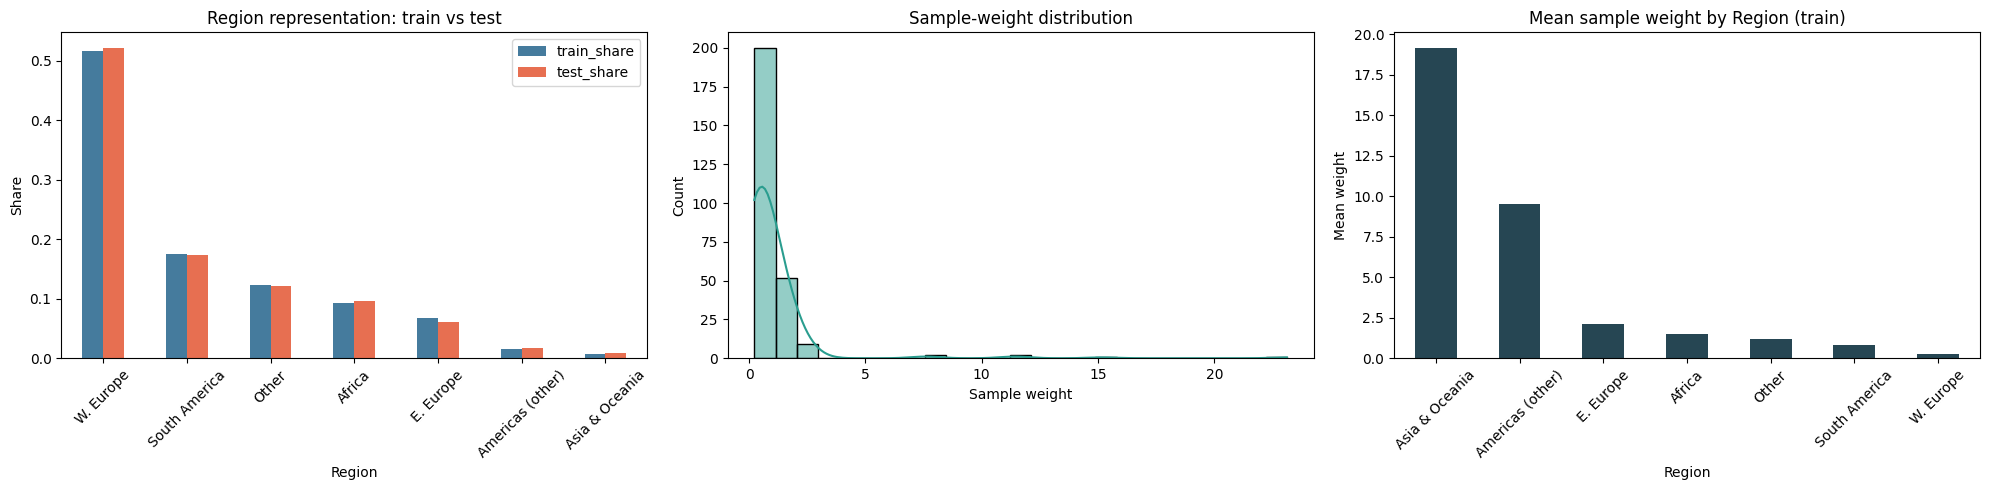

Train/Test Region share comparison:


,train_share,test_share
Region,,
W. Europe,0.517,0.522
South America,0.176,0.174
Other,0.124,0.122
Africa,0.094,0.096
E. Europe,0.067,0.061
Americas (other),0.015,0.017
Asia & Oceania,0.007,0.009


In [21]:
# --- Pre-processing visuals ---
import seaborn as sns
import matplotlib.pyplot as plt

pre_vis_df = pd.DataFrame({
    'Region': context_train['Region'].values,
    'sample_weight': sample_weight_fair
})

train_region_dist = context_train['Region'].value_counts(normalize=True).rename('train_share')
test_region_dist = context_test['Region'].value_counts(normalize=True).rename('test_share')
region_compare = pd.concat([train_region_dist, test_region_dist], axis=1).fillna(0).sort_values('train_share', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

region_compare.plot(kind='bar', ax=axes[0], color=['#457b9d', '#e76f51'])
axes[0].set_title('Region representation: train vs test')
axes[0].set_ylabel('Share')
axes[0].set_xlabel('Region')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(sample_weight_fair, bins=25, kde=True, ax=axes[1], color='#2a9d8f')
axes[1].set_title('Sample-weight distribution')
axes[1].set_xlabel('Sample weight')

region_weight_mean = pre_vis_df.groupby('Region')['sample_weight'].mean().sort_values(ascending=False)
region_weight_mean.plot(kind='bar', ax=axes[2], color='#264653')
axes[2].set_title('Mean sample weight by Region (train)')
axes[2].set_ylabel('Mean weight')
axes[2].set_xlabel('Region')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Train/Test Region share comparison:')
display(region_compare.round(3))

## 10. In-Processing Fairness: Sample-Weighted ADS vs As-Is ADS

Trains two RFs with the same architecture as §8 (`n=270, max_features=650, random_state=169`) and reports them side by side: `rf_asis` (no sample weights) and `rf_weighted` (Region × fee-band sample weights from §9). Each is evaluated on overall performance (RMSE, R²) and on fairness disparity (signed residual gap and MAE gap) across `Region`, `League_from`, and `Nationality` (n ≥ 20 per group).

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


def fairness_eval_regression(y_true, y_pred, groups, min_n=20):
    """Per-group residual diagnostics. Returns sorted table, signed gap, MAE gap."""
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': groups})
    df['residual'] = df['y_pred'] - df['y_true']
    df['abs_error'] = df['residual'].abs()
    g = df.groupby('group').agg(
        n=('residual', 'count'),
        mean_residual=('residual', 'mean'),
        median_residual=('residual', 'median'),
        MAE=('abs_error', 'mean'),
        RMSE=('residual', lambda r: np.sqrt((r ** 2).mean())),
    )
    g = g[g['n'] >= min_n].copy()
    if g.empty:
        return g, np.nan, np.nan
    return (
        g.sort_values('MAE', ascending=False),
        g['mean_residual'].max() - g['mean_residual'].min(),
        g['MAE'].max() - g['MAE'].min(),
    )


# Same architecture as the as-is ADS in section 8; only the sample weights differ.
common_params = dict(n_estimators=270, max_features=650, random_state=169)
variants = [
    ('rf_asis', None),
    ('rf_weighted', sample_weight_fair),
]

trained_models = {}
fairness_tables = {}
results_rows = []

for model_name, sw in variants:
    model = RandomForestRegressor(**common_params)
    if sw is not None:
        model.fit(X_train_fair, y_train_fair, sample_weight=sw)
    else:
        model.fit(X_train_fair, y_train_fair)
    pred_test = model.predict(X_test_fair)

    summary = {
        'model': model_name,
        'RMSE': np.sqrt(mean_squared_error(y_test_fair, pred_test)),
        'R2': r2_score(y_test_fair, pred_test),
    }
    per_group = {}
    for grp_col in ['Region', 'League_from', 'Nationality']:
        if grp_col not in context_test.columns:
            continue
        g_table, signed_gap, mae_gap = fairness_eval_regression(
            y_test_fair.values, pred_test, context_test[grp_col].values, min_n=20,
        )
        per_group[grp_col] = g_table
        summary[f'SignedGap_{grp_col}'] = signed_gap
        summary[f'MAEGap_{grp_col}'] = mae_gap

    trained_models[model_name] = model
    fairness_tables[model_name] = per_group
    results_rows.append(summary)

results_df = pd.DataFrame(results_rows).sort_values(
    ['MAEGap_Region', 'SignedGap_Region', 'RMSE'], ascending=[True, True, True]
).reset_index(drop=True)

print('Model comparison (lower fairness gaps are fairer; sorted by Region MAE gap):')
display(results_df.round(4))

for model_name in trained_models:
    print(f'\n--- {model_name} ---')
    for grp_col, table in fairness_tables[model_name].items():
        print(f'\nBy {grp_col} (n >= 20):')
        display(table.round(4))

Model comparison (lower gaps are fairer):


,model,RMSE,R2,SignedResidualGap_Region,MAEGap_Region
1,rf_weighted,9.0301,0.7523,3.8046,3.4686
0,rf_standard,9.4824,0.7269,4.2124,4.0312
2,rf_conservative,12.3992,0.5330,4.9286,4.5615



Region-level errors for rf_standard:


,n,mean_residual,MAE
group,,,
South America,20,-1.7472,7.6575
W. Europe,60,-0.3190,5.0723
Africa,11,-0.1524,4.2000
Other,14,2.4652,3.6263



Region-level errors for rf_weighted:


,n,mean_residual,MAE
group,,,
South America,20,-1.2996,7.3047
W. Europe,60,-0.3660,5.1259
Africa,11,-0.2470,4.0296
Other,14,2.5050,3.8361



Region-level errors for rf_conservative:


,n,mean_residual,MAE
group,,,
South America,20,-2.0629,8.8407
W. Europe,60,-0.7826,6.1357
Africa,11,-0.3071,4.4409
Other,14,2.8657,4.2792


### 10.1 In-Processing Diagnostics and Visuals

Visual comparison of `rf_asis` and `rf_weighted`:
- RMSE and MAE-gap bars,
- RMSE vs MAE-gap scatter (the fairness-accuracy trade-off),
- residual distribution by model overall and within the top-4 regions.

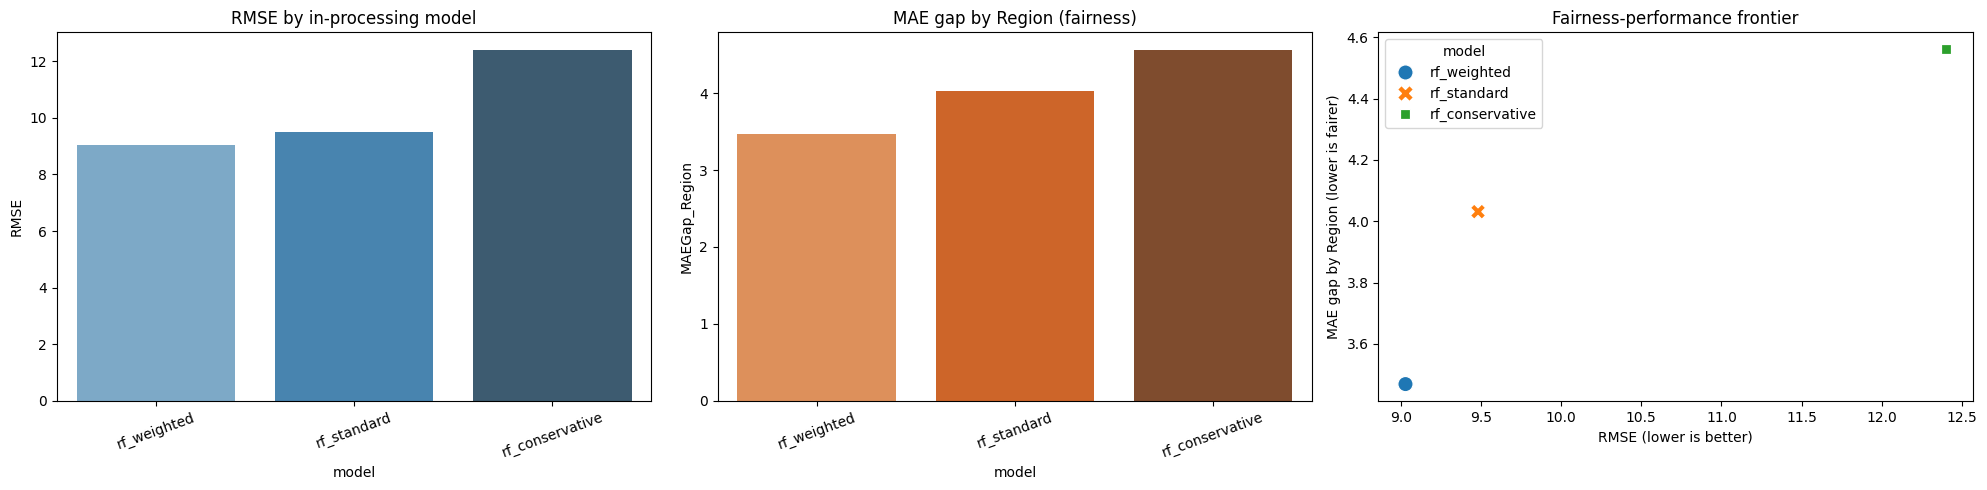

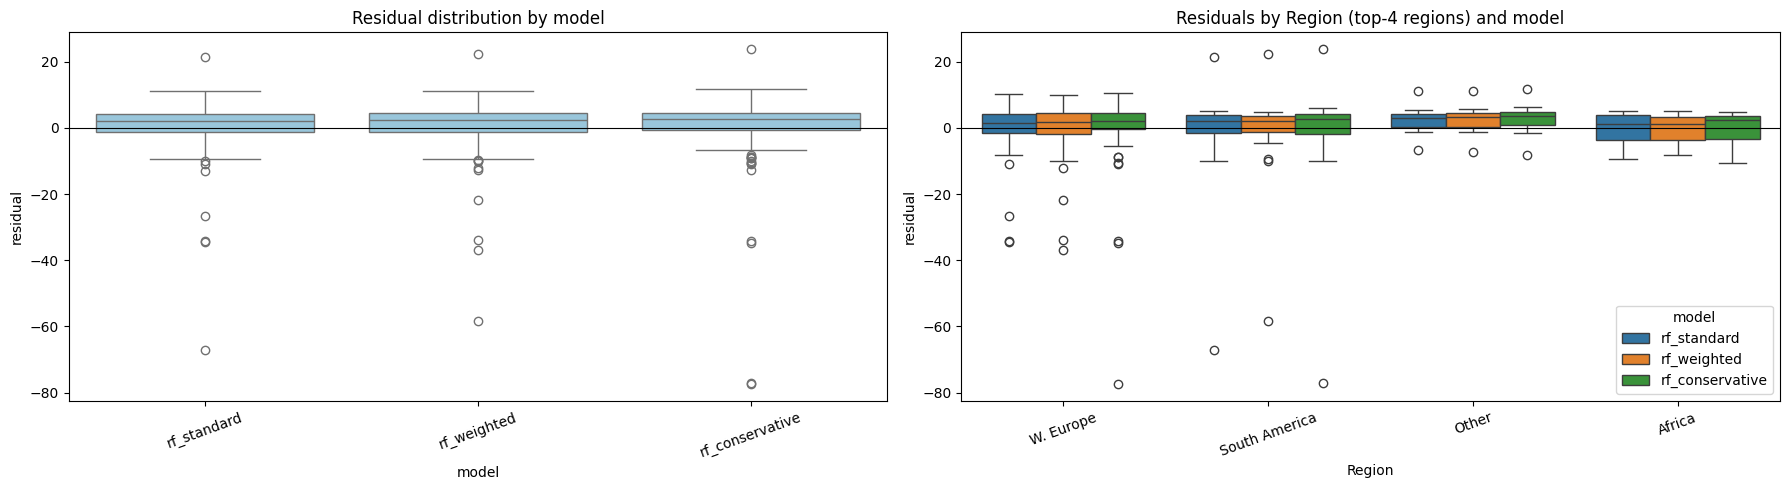

In [23]:
# --- In-processing visuals ---
import seaborn as sns
import matplotlib.pyplot as plt

vis_results = results_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.barplot(data=vis_results, x='model', y='RMSE', hue='model', ax=axes[0], palette='Blues_d', legend=False)
axes[0].set_title('RMSE by in-processing model')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=vis_results, x='model', y='MAEGap_Region', hue='model', ax=axes[1], palette='Oranges_d', legend=False)
axes[1].set_title('MAE gap by Region (fairness)')
axes[1].tick_params(axis='x', rotation=20)

sns.scatterplot(
    data=vis_results,
    x='RMSE', y='MAEGap_Region',
    hue='model', style='model', s=120, ax=axes[2]
)
axes[2].set_title('Fairness-performance frontier')
axes[2].set_xlabel('RMSE (lower is better)')
axes[2].set_ylabel('MAE gap by Region (lower is fairer)')

plt.tight_layout()
plt.show()

# Residual-distribution comparison by model.
residual_rows = []
for model_name, model in trained_models.items():
    pred = model.predict(X_test_fair)
    tmp = pd.DataFrame({
        'model': model_name,
        'residual': pred - y_test_fair.values,
        'Region': context_test['Region'].values
    })
    residual_rows.append(tmp)

residual_plot_df = pd.concat(residual_rows, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.boxplot(data=residual_plot_df, x='model', y='residual', ax=axes[0], color='#8ecae6')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Residual distribution by model')
axes[0].tick_params(axis='x', rotation=20)

region_focus = residual_plot_df[residual_plot_df['Region'].isin(residual_plot_df['Region'].value_counts().head(4).index)]
sns.boxplot(data=region_focus, x='Region', y='residual', hue='model', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals by Region (top-4 regions) and model')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 11. Simpson's Paradox Check on Test Residuals (As-Is ADS)

Tests whether per-Region residual signs from the as-is ADS (`rf_asis`) reverse within finer strata: `League_from` and predicted-fee quintiles. Sign reversals would indicate that aggregate Region findings could mislead readers if reported without strata, which is a relevant disclosure for the deployment recommendation in §5.

In [24]:
# --- Simpson's paradox diagnostics ---
# Audit the as-is ADS, not the mitigation, so this section speaks to the original model.
audit_model_name = 'rf_asis'
audit_model = trained_models[audit_model_name]

simpson_df = context_test.copy()
simpson_df['y_true'] = y_test_fair.values
simpson_df['y_pred'] = audit_model.predict(X_test_fair)
simpson_df['residual'] = simpson_df['y_pred'] - simpson_df['y_true']

# Global residual by Region.
global_region = simpson_df.groupby('Region')['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_global', 'mean': 'global_mean_residual'}
)

# Within-League residual by Region.
within_league = simpson_df.groupby(['League_from', 'Region'])['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_within', 'mean': 'within_mean_residual'}
).reset_index()
within_league = within_league[within_league['n_within'] >= 8]

# Within predicted-fee-bin residual by Region.
simpson_df['pred_bin'] = pd.qcut(simpson_df['y_pred'], q=5, duplicates='drop').astype(str)
within_pred_bin = simpson_df.groupby(['pred_bin', 'Region'])['residual'].agg(['count', 'mean']).rename(
    columns={'count': 'n_within', 'mean': 'within_mean_residual'}
).reset_index()
within_pred_bin = within_pred_bin[within_pred_bin['n_within'] >= 8]


def paradox_flag(global_table, within_table, strata_col):
    rows = []
    for region, g_row in global_table.iterrows():
        g_mean = g_row['global_mean_residual']
        if pd.isna(g_mean) or g_row['n_global'] < 15:
            continue

        region_within = within_table[within_table['Region'] == region]
        if region_within.empty:
            continue

        same_sign_share = np.mean(np.sign(region_within['within_mean_residual']) == np.sign(g_mean))

        rows.append({
            'Region': region,
            'global_mean_residual': g_mean,
            f'strata_count_{strata_col}': region_within[strata_col].nunique(),
            f'same_sign_share_{strata_col}': same_sign_share,
            f'possible_paradox_{strata_col}': same_sign_share < 0.5
        })

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values('global_mean_residual')

paradox_league = paradox_flag(global_region, within_league, 'League_from')
paradox_predbin = paradox_flag(global_region, within_pred_bin, 'pred_bin')

print(f"Simpson diagnostics based on model: {audit_model_name}")
print('\nGlobal residual by Region:')
display(global_region.round(4))

print('\nPotential sign-reversal flags (within League_from strata):')
display(paradox_league.round(4))

print('\nPotential sign-reversal flags (within predicted-fee-bin strata):')
display(paradox_predbin.round(4))

Simpson diagnostics based on model: rf_weighted

Global residual by Region:


,n_global,global_mean_residual
Region,,
Africa,11,-0.2470
Americas (other),2,0.7636
Asia & Oceania,1,2.7781
E. Europe,7,1.8699
Other,14,2.5050
South America,20,-1.2996
W. Europe,60,-0.3660



Potential sign-reversal flags (within League_from strata):


,Region,global_mean_residual,strata_count_League_from,same_sign_share_League_from,possible_paradox_League_from
0,W. Europe,-0.366,2,0.5,False



Potential sign-reversal flags (within predicted-fee-bin strata):


,Region,global_mean_residual,strata_count_pred_bin,same_sign_share_pred_bin,possible_paradox_pred_bin
0,W. Europe,-0.366,5,0.2,True


### 11.1 Simpson's Paradox: Expanded Bucket Analysis

This expands paradox checks to more grouping buckets:
- Age bucket,
- Position bucket,
- League tier,
- Predicted-fee and true-fee bins,
- Region.

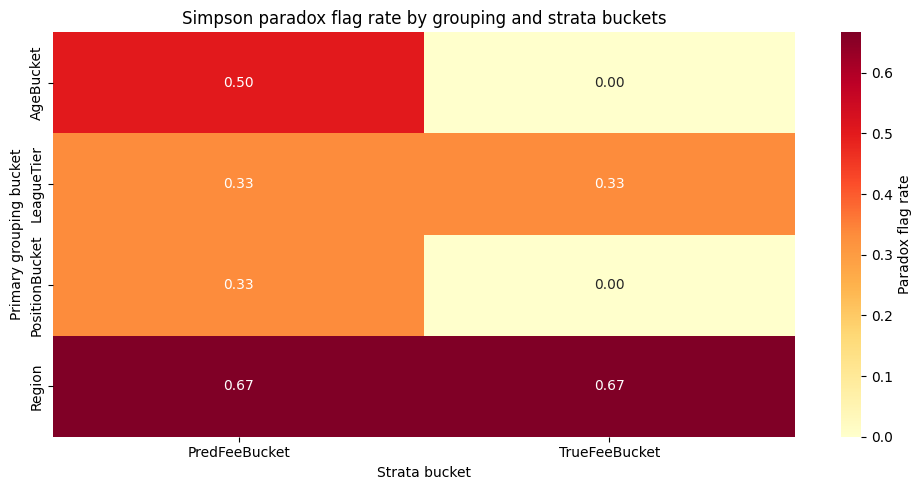

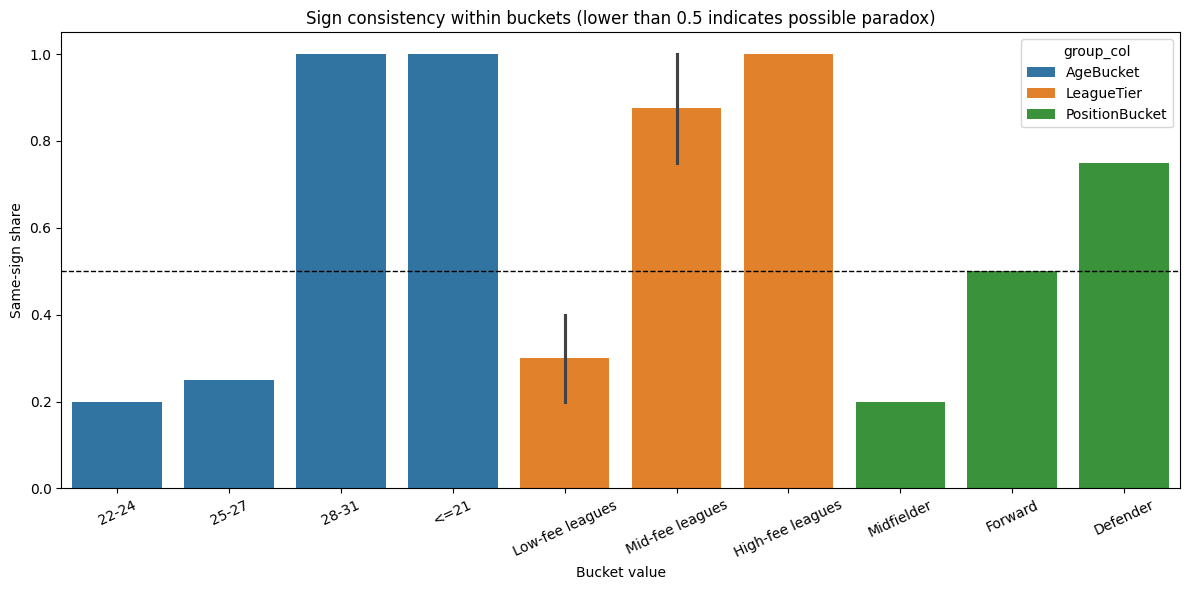

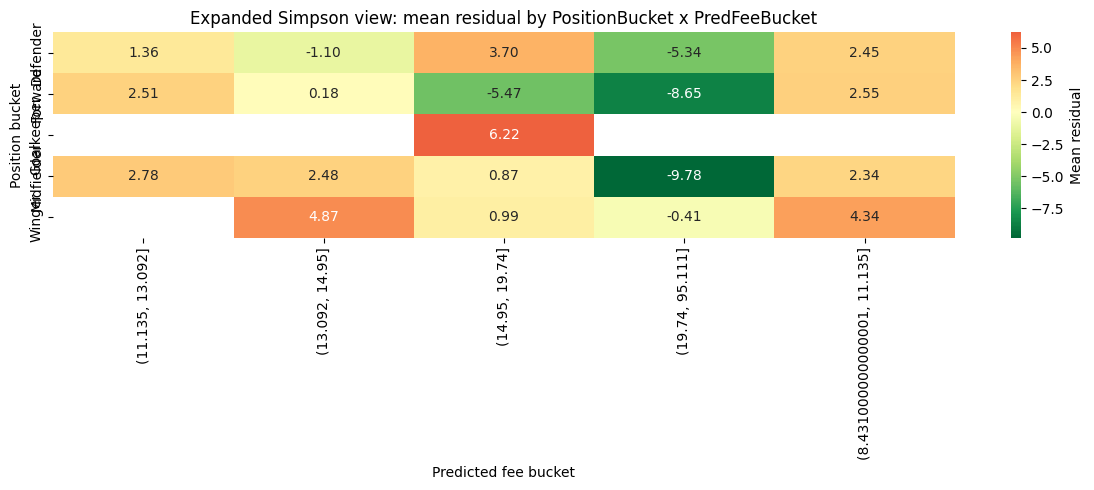

Expanded Simpson paradox table (sample):


,group_col,strata_col,group_value,n_global,global_mean_residual,same_sign_share,possible_paradox
11,PositionBucket,PredFeeBucket,Forward,24.0,-2.091,0.50,False
10,PositionBucket,PredFeeBucket,Defender,30.0,0.696,0.75,False
18,LeagueTier,TrueFeeBucket,Mid-fee leagues,44.0,1.845,0.75,False
0,Region,PredFeeBucket,Other,14.0,2.505,1.00,False
3,Region,TrueFeeBucket,Other,14.0,2.505,1.00,False
8,AgeBucket,PredFeeBucket,28-31,19.0,1.557,1.00,False
9,AgeBucket,PredFeeBucket,<=21,21.0,1.892,1.00,False
13,LeagueTier,PredFeeBucket,High-fee leagues,21.0,-2.826,1.00,False
15,LeagueTier,PredFeeBucket,Mid-fee leagues,44.0,1.845,1.00,False
16,LeagueTier,TrueFeeBucket,High-fee leagues,21.0,-2.826,1.00,False


In [25]:
# --- Expanded Simpson's paradox bucket analysis ---
import seaborn as sns
import matplotlib.pyplot as plt

# Build richer analysis frame using available columns.
if 'base_df' in globals():
    aux_df = base_df.loc[X_test_fair.index].copy()
else:
    aux_df = transfers_cleaned.loc[X_test_fair.index].copy()

simpson_ext = pd.DataFrame(index=X_test_fair.index)
simpson_ext['Region'] = context_test['Region'].values
simpson_ext['League_from'] = context_test['League_from'].values
simpson_ext['y_true'] = y_test_fair.values
simpson_ext['y_pred'] = audit_model.predict(X_test_fair)
simpson_ext['residual'] = simpson_ext['y_pred'] - simpson_ext['y_true']

if 'Age' in aux_df.columns:
    simpson_ext['AgeBucket'] = pd.cut(
        aux_df['Age'].astype(float),
        bins=[0, 21, 24, 27, 31, 60],
        labels=['<=21', '22-24', '25-27', '28-31', '32+'],
        include_lowest=True
    ).astype(str)
else:
    simpson_ext['AgeBucket'] = 'Unknown'

if 'Position' in aux_df.columns:
    pos_map_local = {
        'Centre-Back': 'Defender', 'Left-Back': 'Defender', 'Right-Back': 'Defender', 'Defender': 'Defender',
        'Defensive Midfield': 'Midfielder', 'Central Midfield': 'Midfielder', 'Attacking Midfield': 'Midfielder',
        'Midfielder': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Midfield': 'Midfielder',
        'Left Winger': 'Winger', 'Right Winger': 'Winger',
        'Second Striker': 'Forward', 'Forward': 'Forward', 'Centre-Forward': 'Forward',
        'Goalkeeper': 'Goalkeeper'
    }
    simpson_ext['PositionBucket'] = aux_df['Position'].map(pos_map_local).fillna('Other')
else:
    simpson_ext['PositionBucket'] = 'Unknown'

simpson_ext['PredFeeBucket'] = pd.qcut(simpson_ext['y_pred'], q=5, duplicates='drop').astype(str)
simpson_ext['TrueFeeBucket'] = pd.qcut(simpson_ext['y_true'], q=5, duplicates='drop').astype(str)

# League tier derived from overall median transfer fee in source data.
league_fee_median = transfers_cleaned.groupby('League_from')['Transfer_fee_in_mln'].median()
simpson_ext['LeagueMedianFee'] = simpson_ext['League_from'].map(league_fee_median)
simpson_ext['LeagueTier'] = pd.qcut(simpson_ext['LeagueMedianFee'], q=3, duplicates='drop', labels=['Low-fee leagues', 'Mid-fee leagues', 'High-fee leagues']).astype(str)


def paradox_grid(df, group_col, strata_col, min_global=12, min_within=6):
    global_tab = df.groupby(group_col)['residual'].agg(['count', 'mean']).rename(columns={'count': 'n_global', 'mean': 'global_mean'})
    within_tab = df.groupby([strata_col, group_col])['residual'].agg(['count', 'mean']).rename(columns={'count': 'n_within', 'mean': 'within_mean'}).reset_index()
    within_tab = within_tab[within_tab['n_within'] >= min_within]

    rows = []
    for g, row in global_tab.iterrows():
        if row['n_global'] < min_global:
            continue
        g_slice = within_tab[within_tab[group_col] == g]
        if g_slice.empty:
            continue

        same_sign_share = (np.sign(g_slice['within_mean']) == np.sign(row['global_mean'])).mean()
        rows.append({
            'group_col': group_col,
            'strata_col': strata_col,
            'group_value': g,
            'n_global': row['n_global'],
            'global_mean_residual': row['global_mean'],
            'same_sign_share': same_sign_share,
            'possible_paradox': same_sign_share < 0.5
        })

    return pd.DataFrame(rows)

analysis_pairs = [
    ('Region', 'PredFeeBucket'),
    ('Region', 'TrueFeeBucket'),
    ('AgeBucket', 'PredFeeBucket'),
    ('PositionBucket', 'PredFeeBucket'),
    ('LeagueTier', 'PredFeeBucket'),
    ('LeagueTier', 'TrueFeeBucket'),
]

paradox_frames = []
for gcol, scol in analysis_pairs:
    out = paradox_grid(simpson_ext, gcol, scol)
    if not out.empty:
        paradox_frames.append(out)

if len(paradox_frames) == 0:
    raise ValueError('No expanded paradox outputs were produced. Consider lowering min thresholds.')

paradox_expanded = pd.concat(paradox_frames, ignore_index=True)

summary_heat = paradox_expanded.groupby(['group_col', 'strata_col'])['possible_paradox'].mean().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(summary_heat, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Paradox flag rate'})
plt.title('Simpson paradox flag rate by grouping and strata buckets')
plt.xlabel('Strata bucket')
plt.ylabel('Primary grouping bucket')
plt.tight_layout()
plt.show()

# Visualize sign consistency for key expanded groups.
focus = paradox_expanded[paradox_expanded['group_col'].isin(['AgeBucket', 'PositionBucket', 'LeagueTier'])].copy()
focus = focus.sort_values(['group_col', 'same_sign_share'])

plt.figure(figsize=(12, 6))
sns.barplot(data=focus, x='group_value', y='same_sign_share', hue='group_col')
plt.axhline(0.5, color='black', linestyle='--', linewidth=1)
plt.title('Sign consistency within buckets (lower than 0.5 indicates possible paradox)')
plt.xlabel('Bucket value')
plt.ylabel('Same-sign share')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Residual heatmap for one expanded view: PositionBucket x PredFeeBucket.
pos_pred_pivot = simpson_ext.groupby(['PositionBucket', 'PredFeeBucket'])['residual'].mean().unstack()
plt.figure(figsize=(12, 5))
sns.heatmap(pos_pred_pivot, annot=True, fmt='.2f', center=0, cmap='RdYlGn_r', cbar_kws={'label': 'Mean residual'})
plt.title('Expanded Simpson view: mean residual by PositionBucket x PredFeeBucket')
plt.xlabel('Predicted fee bucket')
plt.ylabel('Position bucket')
plt.tight_layout()
plt.show()

print('Expanded Simpson paradox table (sample):')
display(paradox_expanded.sort_values(['possible_paradox', 'same_sign_share']).head(20).round(3))

## 12. Hierarchical Strategy: Global Model + Group Residual Models

This section trains a hierarchical approach:
- a global random forest for base signal,
- per-region residual models for groups with enough training data,
- fallback to global-only predictions for sparse groups.

In [26]:
# --- Hierarchical model training ---
min_group_n = 80

# Global model uses fairness-aware sample weights from Section 9.
global_model = RandomForestRegressor(
    n_estimators=350,
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=169
)
global_model.fit(X_train_fair, y_train_fair, sample_weight=sample_weight_fair)

# Train-group residual targets.
global_pred_train = global_model.predict(X_train_fair)
residual_train = y_train_fair.values - global_pred_train

train_h = X_train_fair.copy()
train_h['Region'] = context_train['Region'].values
train_h['residual_target'] = residual_train

# Fit one residual model per sufficiently large Region.
region_models = {}
region_counts = train_h['Region'].value_counts()
eligible_regions = region_counts[region_counts >= min_group_n].index.tolist()

for region in eligible_regions:
    subset = train_h[train_h['Region'] == region]
    X_r = subset.drop(columns=['Region', 'residual_target'])
    y_r = subset['residual_target'].values

    # Small residual model to avoid overfitting sparse local structure.
    region_model = RandomForestRegressor(
        n_estimators=120,
        max_features='sqrt',
        min_samples_leaf=8,
        random_state=169
    )
    region_model.fit(X_r, y_r)
    region_models[region] = region_model

# Predict on test set: global + optional region residual correction.
global_pred_test = global_model.predict(X_test_fair)
hier_pred_test = global_pred_test.copy()

for i, idx in enumerate(X_test_fair.index):
    region = context_test.loc[idx, 'Region']
    if region in region_models:
        row_features = X_test_fair.loc[[idx]]
        correction = region_models[region].predict(row_features)[0]
        hier_pred_test[i] += correction

# Compare hierarchical against best in-processing single model.
best_single_name = results_df.iloc[0]['model']
best_single_model = trained_models[best_single_name]
best_single_pred = best_single_model.predict(X_test_fair)

comparison_rows = []
for label, preds in [
    (f'single_{best_single_name}', best_single_pred),
    ('hierarchical_global_plus_region', hier_pred_test)
]:
    rmse = np.sqrt(mean_squared_error(y_test_fair, preds))
    r2 = r2_score(y_test_fair, preds)
    fair_tbl, signed_gap, mae_gap = fairness_eval_regression(
        y_true=y_test_fair.values,
        y_pred=preds,
        groups=context_test['Region'].values
    )

    comparison_rows.append({
        'model': label,
        'RMSE': rmse,
        'R2': r2,
        'SignedResidualGap_Region': signed_gap,
        'MAEGap_Region': mae_gap,
        'RegionsWithResidualModel': len(region_models)
    })

hier_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ['MAEGap_Region', 'SignedResidualGap_Region', 'RMSE'],
    ascending=[True, True, True]
)

print('Hierarchical strategy comparison:')
display(hier_comparison_df.round(4))

print('Regions with local residual models:')
print(sorted(region_models.keys()))

Hierarchical strategy comparison:


,model,RMSE,R2,SignedResidualGap_Region,MAEGap_Region,RegionsWithResidualModel
0,single_rf_weighted,9.0301,0.7523,3.8046,3.4686,1
1,hierarchical_global_plus_region,9.4919,0.7263,3.9991,3.8903,1


Regions with local residual models:
['W. Europe']


## 13. Interpretability and Uncertainty (As-Is ADS)

Three additional audits on the as-is ADS (`rf_asis`):
- **SHAP** (§13.1): global feature importance and top-feature dependence.
- **LIME** (§13.2): local drivers for a top-decile vs bottom-decile predicted-fee transfer, to test whether the model relies on different signals at the extremes.
- **PDP and ICE** (§13.3): average marginal effect vs individual spread for the top-3 features, paired side by side.
- **Conformal prediction** (§13.4): calibrated 90% prediction intervals and region-level coverage, to support the §5 deployment recommendation.

In [27]:
# --- Explainability setup (model, data, and dependencies) ---
import sys
import subprocess
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import PartialDependenceDisplay


def _ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"Installing {pkg_name}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])
        return importlib.import_module(import_name)


shap = _ensure_package('shap')
_ensure_package('lime')
from lime.lime_tabular import LimeTabularExplainer

# Explain the as-is ADS (the audited model), matching sections 11 and 13.4.
explanation_model_name = 'rf_asis'
explanation_model = trained_models[explanation_model_name]
X_train_exp = X_train_fair.copy()
X_test_exp = X_test_fair.copy()
y_test_exp = y_test_fair.copy()

feature_importance = pd.Series(
    explanation_model.feature_importances_,
    index=X_train_exp.columns
).sort_values(ascending=False)

# Favor features with richer value ranges for ICE/PDP readability.
continuous_like = [c for c in X_train_exp.columns if X_train_exp[c].nunique() > 10]
pdp_candidate_features = [c for c in feature_importance.index if c in continuous_like][:4]
if len(pdp_candidate_features) < 4:
    extras = [c for c in continuous_like if c not in pdp_candidate_features]
    pdp_candidate_features = (pdp_candidate_features + extras)[:4]

print(f'Explainability model: {explanation_model_name}')
print('Train shape:', X_train_exp.shape, '| Test shape:', X_test_exp.shape)
print('\nTop features by importance:')
display(feature_importance.head(12).round(5))
print('PDP/ICE features:', pdp_candidate_features)

Explainability model: rf_weighted
Train shape: (267, 37) | Test shape: (115, 37)

Top features by importance:


Market_value_in_mln           0.27408
potential                     0.22391
overall                       0.14684
league_median_fee_to          0.04708
Age                           0.03343
season_mean_fee               0.02877
Season_transferred            0.02455
League_from_Other             0.01673
League_to_Premier League      0.01505
League_from_LaLiga            0.01317
League_from_Premier League    0.01246
age_bucket_20-23              0.01227
dtype: float64

PDP/ICE features: ['Market_value_in_mln', 'potential', 'overall', 'league_median_fee_to']


### 13.1 SHAP — Global Importance and Top-Feature Dependence

Global SHAP views (beeswarm and mean-|SHAP| bar) on a 300-row sample of `X_test_fair`, plus a dependence plot for the single most-important feature.

In [ ]:
# --- SHAP global views on a sample of the test set ---
import matplotlib.pyplot as plt

sample_n = min(300, len(X_test_exp))
X_shap = X_test_exp.sample(sample_n, random_state=42)

print('Computing SHAP values...')
shap_explainer = shap.TreeExplainer(explanation_model)
shap_values = shap_explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Beeswarm: per-feature contribution distribution across the sample.
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title(f'SHAP global feature importance (beeswarm) - {explanation_model_name}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Bar: mean absolute SHAP per feature.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=12, show=False)
plt.title(f'Mean |SHAP| - {explanation_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Dependence plot for the single top feature.
dep_feature = feature_importance.index[0]
fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(dep_feature, shap_values, X_shap,
                     interaction_index=None, show=False, ax=ax)
ax.set_title(f'SHAP dependence: {dep_feature}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nSHAP computed on {len(shap_values)} instances of the as-is ADS test set.')

### 13.2 LIME - Top vs Bottom Predicted-Fee Contrast

Two LIME explanations: the test instance with the highest predicted fee and the one with the lowest. The side-by-side bars show whether the model relies on the same features (e.g. Market_value, overall) at both extremes, or whether different signals dominate cheap vs expensive predictions.

In [ ]:
# --- LIME: top-decile vs bottom-decile predicted-fee transfers ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'LimeTabularExplainer' not in globals():
    raise ValueError('Run the explainability setup cell before this section.')

def predict_for_lime(arr):
    arr_df = pd.DataFrame(arr, columns=X_train_exp.columns)
    return explanation_model.predict(arr_df)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_exp.values,
    feature_names=X_train_exp.columns.tolist(),
    mode='regression',
    discretize_continuous=True,
    random_state=42,
)

# Pick one transfer near the top of predicted fee and one near the bottom.
test_pred = explanation_model.predict(X_test_exp)
pred_series = pd.Series(test_pred, index=X_test_exp.index)
cases = [
    ('Top-fee',    pred_series.idxmax()),
    ('Bottom-fee', pred_series.idxmin()),
]

def explain_instance(row_idx):
    row = X_test_exp.loc[row_idx].values
    exp = lime_explainer.explain_instance(row, predict_for_lime, num_features=10)
    return pd.DataFrame(exp.as_list(), columns=['feature', 'weight'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
summary_rows = []
for ax, (label, idx) in zip(axes, cases):
    actual = float(y_test_exp.loc[idx])
    predicted = float(pred_series.loc[idx])
    lime_df = explain_instance(idx).sort_values('weight')
    colors = ['#2a9d8f' if v > 0 else '#e76f51' for v in lime_df['weight']]
    ax.barh(lime_df['feature'], lime_df['weight'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label} | actual EUR {actual:.2f}M | pred EUR {predicted:.2f}M',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('LIME local contribution')
    ax.grid(axis='x', alpha=0.25)
    top_pos = lime_df[lime_df['weight'] > 0].sort_values('weight', ascending=False).head(3)
    top_neg = lime_df[lime_df['weight'] < 0].sort_values('weight').head(3)
    summary_rows.append({
        'Case': label,
        'Actual fee (M)': round(actual, 2),
        'Predicted fee (M)': round(predicted, 2),
        'Top positive drivers': '; '.join(top_pos['feature'].tolist()),
        'Top negative drivers': '; '.join(top_neg['feature'].tolist()),
    })

plt.tight_layout()
plt.show()

print('Top vs bottom predicted-fee LIME contrast:')
display(pd.DataFrame(summary_rows))

### 13.3 PDP and ICE - Average Effect vs Individual Spread

For the top-3 most-important features, paired plots: PDP (left, average marginal effect) and ICE (right, per-instance curves on a random subsample). Use the pairing to spot cases where the average masks heterogeneity across players.

In [ ]:
# --- PDP (left) and ICE (right) side-by-side per feature ---
import numpy as np

if len(pdp_candidate_features) == 0:
    raise ValueError('No suitable features found for PDP/ICE. Check feature engineering output.')

pdp_features = pdp_candidate_features[:3]

fig, axes = plt.subplots(len(pdp_features), 2, figsize=(14, 4 * len(pdp_features)))
if len(pdp_features) == 1:
    axes = np.array([axes])

for i, feat in enumerate(pdp_features):
    PartialDependenceDisplay.from_estimator(
        explanation_model, X_test_exp, [feat],
        kind='average', grid_resolution=25, ax=axes[i, 0],
    )
    axes[i, 0].set_title(f'PDP - {feat}')

    PartialDependenceDisplay.from_estimator(
        explanation_model, X_test_exp, [feat],
        kind='individual', subsample=min(80, len(X_test_exp)),
        random_state=42, grid_resolution=25, ax=axes[i, 1],
    )
    axes[i, 1].set_title(f'ICE - {feat}')

plt.tight_layout()
plt.show()

### 13.4 Conformal Prediction - Calibrated 90% Intervals

Split conformal prediction on the as-is ADS (`rf_asis`): partition training data into fit and calibration splits, fit a fresh model with the same hyperparameters as `rf_asis` (`n_estimators=270, max_features=650, random_state=169`), and use absolute residuals on the calibration split to set the 90% conformal radius. Reports empirical coverage on the test set and per-Region coverage to check whether the interval is fair across groups.

In [ ]:
# --- 90% conformal prediction on the as-is ADS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

conformal_model_name = 'rf_asis'

# Calibration split from training only (no test leakage).
rng = np.random.default_rng(69)
train_idx = np.array(X_train_fair.index)
if len(train_idx) < 40:
    raise ValueError('Not enough training rows for conformal calibration.')

calibration_size = max(30, int(round(0.2 * len(train_idx))))
calibration_size = min(calibration_size, len(train_idx) - 20)
perm = rng.permutation(train_idx)
calibration_idx = perm[:calibration_size]
fit_idx = perm[calibration_size:]

X_fit_conf = X_train_fair.loc[fit_idx].copy()
y_fit_conf = y_train_fair.loc[fit_idx].copy()
X_cal_conf = X_train_fair.loc[calibration_idx].copy()
y_cal_conf = y_train_fair.loc[calibration_idx].copy()

# Fresh model with the same hyperparameters as the as-is ADS, fit on the fit split only.
conformal_fit_model = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
conformal_fit_model.fit(X_fit_conf, y_fit_conf)

# Absolute residuals on the calibration split define the conformal radius.
cal_pred = conformal_fit_model.predict(X_cal_conf)
cal_residuals = np.abs(y_cal_conf.values - cal_pred)
alpha = 0.10
conformal_q = np.quantile(
    cal_residuals,
    np.ceil((len(cal_residuals) + 1) * (1 - alpha)) / len(cal_residuals),
    method='higher',
)

# 90% intervals on the held-out test set.
test_pred = conformal_fit_model.predict(X_test_fair)
lower_bound = test_pred - conformal_q
upper_bound = test_pred + conformal_q
covered = (y_test_fair.values >= lower_bound) & (y_test_fair.values <= upper_bound)
interval_width = upper_bound - lower_bound

conformal_results = pd.DataFrame({
    'actual_fee_mln': y_test_fair.values,
    'predicted_fee_mln': test_pred,
    'lower_90_mln': lower_bound,
    'upper_90_mln': upper_bound,
    'interval_width_mln': interval_width,
    'covered': covered,
    'Region': context_test['Region'].values,
}, index=X_test_fair.index)

print(f'90% conformal model: {conformal_model_name} (n=270, max_features=650, random_state=169)')
print(f'Calibration rows: {len(X_cal_conf)} | Fit rows: {len(X_fit_conf)}')
print(f'Empirical coverage on test: {covered.mean():.3f}')
print(f'Median interval width: {np.median(interval_width):.3f} M EUR')
print(f'90th-percentile residual radius: {conformal_q:.3f} M EUR')
display(conformal_results.head(15).round(3))

# Coverage by Region to check that intervals are calibrated fairly across groups.
region_coverage = conformal_results.groupby('Region').agg(
    n=('covered', 'count'),
    coverage=('covered', 'mean'),
    mean_width=('interval_width_mln', 'mean'),
    mae=('actual_fee_mln', lambda s: float(np.mean(np.abs(s - conformal_results.loc[s.index, 'predicted_fee_mln'])))),
).sort_values('coverage', ascending=False)

print('Region-level conformal coverage:')
display(region_coverage.round(3))

# Predicted vs actual with 90% conformal band.
plot_df = conformal_results.sort_values('predicted_fee_mln').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(plot_df.index, plot_df['actual_fee_mln'], color='#264653', linewidth=1.2, label='Actual fee')
ax.plot(plot_df.index, plot_df['predicted_fee_mln'], color='#2a9d8f', linewidth=1.5, label='Predicted fee')
ax.fill_between(plot_df.index, plot_df['lower_90_mln'], plot_df['upper_90_mln'],
                color='#f4a261', alpha=0.25, label='90% conformal interval')
ax.set_title('90% conformal prediction on the as-is ADS')
ax.set_xlabel('Test instance rank')
ax.set_ylabel('Transfer fee (M EUR)')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 15. Counterfactual Fairness Audit (Shadow Model)

The as-is ADS is intentionally blind to Region, but bias can still leak through proxies (League, Team, Market_value). To quantify this, we train a **shadow model** with the same hyperparameters as `rf_asis` plus Region one-hot dummies as input features. We then compare two predictions per non-W.Europe test player: shadow as-is vs. shadow with Region swapped to W. Europe. The gap is the **geographic premium** a Region-aware version of the same architecture would apply to identical performance stats. A second comparison against the blind `rf_asis` shows how much of that premium is already encoded through proxies.

In [ ]:
# --- Counterfactual fairness audit via a Region-aware shadow model ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

if 'audit_model' not in globals() or 'X_train_fair' not in globals():
    raise RuntimeError('Run sections 8-11 first; audit_model and the fair split must exist.')

# Build shadow feature matrices: same as the as-is ADS, plus Region one-hot dummies.
region_train_dum = pd.get_dummies(context_train['Region'], prefix='Region')
region_test_dum = pd.get_dummies(context_test['Region'], prefix='Region')
region_train_dum, region_test_dum = region_train_dum.align(region_test_dum, join='outer', axis=1, fill_value=0)

X_train_shadow = pd.concat([X_train_fair, region_train_dum], axis=1)
X_test_shadow = pd.concat([X_test_fair, region_test_dum], axis=1)

# Same hyperparameters as rf_asis; only the feature set differs (Region added).
shadow_model = RandomForestRegressor(n_estimators=270, max_features=650, random_state=169)
shadow_model.fit(X_train_shadow, y_train_fair)
print(f'Shadow model trained on {X_train_shadow.shape[1]} features '
      f'(rf_asis features + {region_train_dum.shape[1]} Region dummies).')

# Counterfactual helper: swap any Region dummies to a single target region.
region_cols = [c for c in X_train_shadow.columns if c.startswith('Region_')]
target_region_col = 'Region_W. Europe'
if target_region_col not in region_cols:
    raise RuntimeError(f'{target_region_col} missing from shadow feature space.')

def swap_to_w_europe(X):
    Xc = X.copy()
    Xc[region_cols] = 0
    Xc[target_region_col] = 1
    return Xc

# Case studies: top-2 highest-fee non-W.Europe test players.
non_we_mask = context_test['Region'] != 'W. Europe'
non_we_test = X_test_shadow[non_we_mask].copy()
non_we_y = y_test_fair[non_we_mask].copy()
case_idx = non_we_y.sort_values(ascending=False).head(2).index

case_rows = []
for idx in case_idx:
    orig_vec = X_test_shadow.loc[[idx]]
    cf_vec = swap_to_w_europe(orig_vec)
    audit_vec = X_test_fair.loc[[idx]]
    case_rows.append({
        'Player index': idx,
        'Region (actual)': context_test.loc[idx, 'Region'],
        'Actual fee (M)': float(y_test_fair.loc[idx]),
        'rf_asis (blind, M)': float(audit_model.predict(audit_vec)[0]),
        'Shadow original (M)': float(shadow_model.predict(orig_vec)[0]),
        'Shadow swapped to W.Europe (M)': float(shadow_model.predict(cf_vec)[0]),
    })

case_df = pd.DataFrame(case_rows)
case_df['Geographic premium (M)'] = (
    case_df['Shadow swapped to W.Europe (M)'] - case_df['Shadow original (M)']
)
print('\nCounterfactual case studies (top-2 highest-fee non-W.Europe test players):')
display(case_df.round(2))

# Batch counterfactual sweep across every non-W.Europe test player.
preds_orig = shadow_model.predict(non_we_test)
preds_swapped = shadow_model.predict(swap_to_w_europe(non_we_test))
disparity = preds_swapped - preds_orig

print(f'\nBatch counterfactual: swapped {len(disparity)} non-W.Europe test players to W. Europe.')
print(f'  Mean geographic premium:   {disparity.mean():+.2f} M EUR')
print(f'  Median premium:            {np.median(disparity):+.2f} M EUR')
print(f'  Max premium:               {disparity.max():+.2f} M EUR')
print(f'  Share with positive premium: {(disparity > 0).mean():.1%}')

plt.figure(figsize=(10, 5))
sns.histplot(disparity, kde=True, color='#7b2cbf', bins=30)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(disparity.mean(), color='#e76f51', linestyle='-', linewidth=1.5,
            label=f'Mean = {disparity.mean():+.2f} M')
plt.title('Geographic premium: shadow model when non-W.Europe players are swapped to W. Europe')
plt.xlabel('Fee change (M EUR)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()